In [127]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [128]:
df=pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [129]:
df.head()
# df.info()
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='count'>

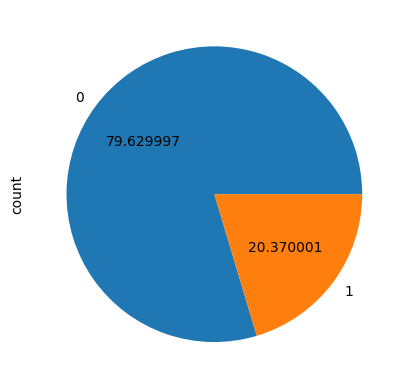

In [130]:
df['Exited'].value_counts().plot(kind='pie',autopct='%2f')

In [131]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [132]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [133]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [134]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [135]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [136]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

trf=ColumnTransformer(transformers=[('trf1',OneHotEncoder(),['Gender','Geography']),('trf2',StandardScaler(),['Balance','EstimatedSalary'])],remainder='passthrough')
dff=trf.fit_transform(df)
dff=pd.DataFrame(dff,columns=trf.get_feature_names_out())
dff

,trf1__Gender_Female,trf1__Gender_Male,trf1__Geography_France,trf1__Geography_Germany,trf1__Geography_Spain,trf2__Balance,trf2__EstimatedSalary,remainder__CreditScore,remainder__Age,remainder__Tenure,remainder__NumOfProducts,remainder__HasCrCard,remainder__IsActiveMember,remainder__Exited
0,1.0,0.0,1.0,0.0,0.0,-1.225848,0.021886,619.0,42.0,2.0,1.0,1.0,1.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.117350,0.216534,608.0,41.0,1.0,1.0,0.0,1.0,0.0
2,1.0,0.0,1.0,0.0,0.0,1.333053,0.240687,502.0,42.0,8.0,3.0,1.0,0.0,1.0
3,1.0,0.0,1.0,0.0,0.0,-1.225848,-0.108918,699.0,39.0,1.0,2.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.785728,-0.365276,850.0,43.0,2.0,1.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.0,1.0,1.0,0.0,0.0,-1.225848,-0.066419,771.0,39.0,5.0,2.0,1.0,0.0,0.0
9996,0.0,1.0,1.0,0.0,0.0,-0.306379,0.027988,516.0,35.0,10.0,1.0,1.0,1.0,0.0
9997,1.0,0.0,1.0,0.0,0.0,-1.225848,-1.008643,709.0,36.0,7.0,1.0,0.0,1.0,1.0
9998,0.0,1.0,0.0,1.0,0.0,-0.022608,-0.125231,772.0,42.0,3.0,2.0,1.0,0.0,1.0


In [137]:
print(df['Balance'].mean())
print(dff['trf2__Balance'].mean())


76485.889288
-6.252776074688882e-17


<Axes: xlabel='trf2__Balance', ylabel='Density'>

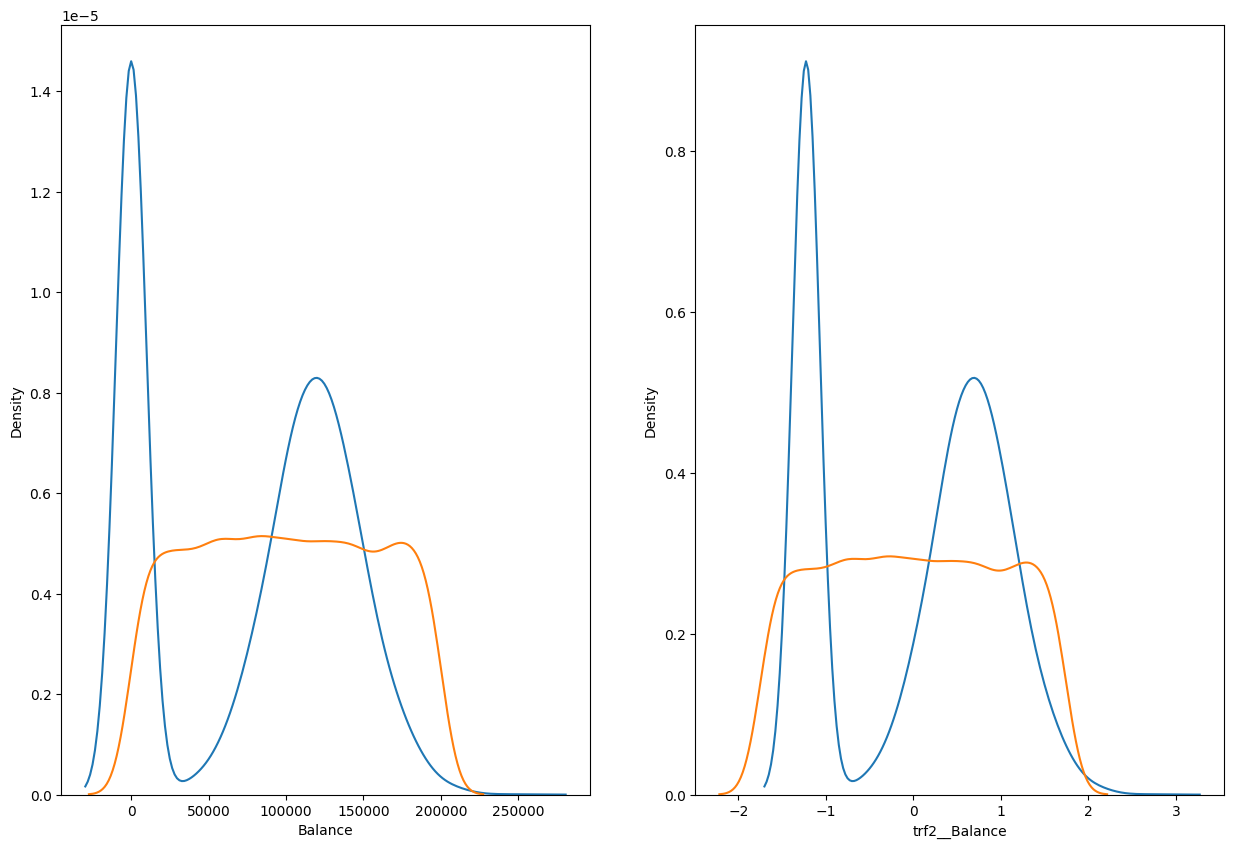

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, (ax1,ax2)=plt.subplots(1,2,figsize=(15,10))
sns.kdeplot(df['Balance'],ax=ax1)
sns.kdeplot(df['EstimatedSalary'],ax=ax1)
sns.kdeplot(dff['trf2__Balance'],ax=ax2)
sns.kdeplot(dff['trf2__EstimatedSalary'],ax=ax2)

In [139]:
# Check the raw numerical ranges before vs after
print("--- BEFORE SCALING ---")
print(df[["Balance", "EstimatedSalary"]].describe().loc[["min", "max"]])

print("\n--- AFTER SCALING ---")
print(dff[["trf2__Balance", "trf2__EstimatedSalary"]].describe().loc[["min", "max"]])


--- BEFORE SCALING ---
       Balance  EstimatedSalary
min       0.00            11.58
max  250898.09        199992.48

--- AFTER SCALING ---
     trf2__Balance  trf2__EstimatedSalary
min      -1.225848              -1.740268
max       2.795323               1.737200


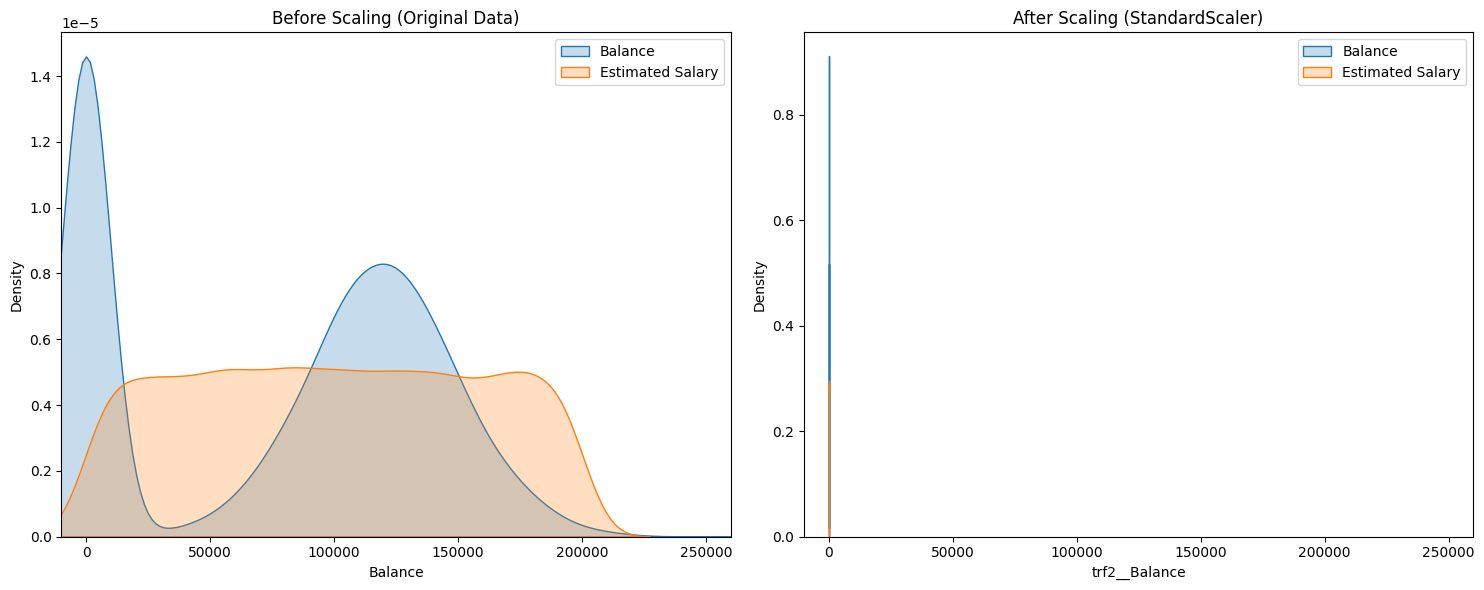

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Before Scaling
sns.kdeplot(df["Balance"], ax=ax1, label="Balance", fill=True)
sns.kdeplot(df["EstimatedSalary"], ax=ax1, label="Estimated Salary", fill=True)
ax1.set_title("Before Scaling (Original Data)")
ax1.legend()

# 2. After Scaling
sns.kdeplot(dff["trf2__Balance"], ax=ax2, label="Balance", fill=True)
sns.kdeplot(dff["trf2__EstimatedSalary"], ax=ax2, label="Estimated Salary", fill=True)
ax2.set_title("After Scaling (StandardScaler)")
ax2.legend()

# 🚨 THE FIX: Force both plots to show the original massive scale (0 to 250,000)
# This will show you how tiny and tightly grouped the scaled data looks compared to the raw data!
ax1.set_xlim(-10000, 260000)
ax2.set_xlim(-10000, 260000)

fig.tight_layout()
plt.show()


In [141]:

x=dff.drop(columns='remainder__Exited')
y=dff.iloc[:,-1]
y

0       1.0
1       0.0
2       1.0
3       0.0
4       0.0
       ... 
9995    0.0
9996    0.0
9997    1.0
9998    1.0
9999    0.0
Name: remainder__Exited, Length: 10000, dtype: float64

In [142]:
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test=train_test_split(x,y)

In [143]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   trf1__Gender_Female        10000 non-null  float64
 1   trf1__Gender_Male          10000 non-null  float64
 2   trf1__Geography_France     10000 non-null  float64
 3   trf1__Geography_Germany    10000 non-null  float64
 4   trf1__Geography_Spain      10000 non-null  float64
 5   trf2__Balance              10000 non-null  float64
 6   trf2__EstimatedSalary      10000 non-null  float64
 7   remainder__CreditScore     10000 non-null  float64
 8   remainder__Age             10000 non-null  float64
 9   remainder__Tenure          10000 non-null  float64
 10  remainder__NumOfProducts   10000 non-null  float64
 11  remainder__HasCrCard       10000 non-null  float64
 12  remainder__IsActiveMember  10000 non-null  float64
dtypes: float64(13)
memory usage: 1015.8 KB


In [144]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense
model=Sequential()
model.add(Dense(3,activation='relu',input_dim=13))
model.add(Dense(3,activation='relu'))

model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [145]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58 (232.00 B)

 Trainable params: 58 (232.00 B)

 Non-trainable params: 0 (0.00 B)

In [159]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=100,validation_split=0.2)


Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8130 - loss: 0.4316 - val_accuracy: 0.8140 - val_loss: 0.4367
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8092 - loss: 0.4317 - val_accuracy: 0.8073 - val_loss: 0.4430
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8088 - loss: 0.4292 - val_accuracy: 0.8140 - val_loss: 0.4366
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8130 - loss: 0.4305 - val_accuracy: 0.8133 - val_loss: 0.4449
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8098 - loss: 0.4311 - val_accuracy: 0.8153 - val_loss: 0.4365
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8117 - loss: 0.4286 - val_accuracy: 0.8027 - val_loss: 0.4500
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8142 - loss: 0.4293 - val_accuracy: 0.8127 - val_loss: 0.4380
Epoch 8/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8118 - loss: 0.4286 - val_accu

In [147]:
model.layers[2].get_weights()

[array([[-0.1171822 ],
        [ 0.20246398],
        [ 0.9561028 ]], dtype=float32),
 array([0.01454666], dtype=float32)]

In [160]:
y_log=model.predict(x_test)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [161]:
y_log.shape[0]

2500

In [162]:
y_pred=np.where(y_log<0.5,0,1)
y_pred[3]

array([1])

In [163]:
y_log[3]

array([0.8296451], dtype=float32)

The training accuracy (accuracy) that prints out on your screen is precisely the score calculated by running the entire 80% training set through the model using the final weights established at the very end of that epoch.
To completely solidify your mental map, here is the exact order of events at the finish line of an epoch:
1. The model finishes the last batch of the 80% training data.
2. Keras pauses the training.
3. Training Accuracy Check: Keras passes the entire 80% training set through the network one time (without changing any weights) to calculate and print your accuracy.
4. Validation Accuracy Check: Keras passes your isolated 20% validation set through the network one time to calculate and print your val_accuracy.
5. The epoch terminates, and the next epoch begins using those final weights as the starting point.


In [165]:

from sklearn.metrics import accuracy_score 
accuracy_score(y_test,y_pred)

0.808

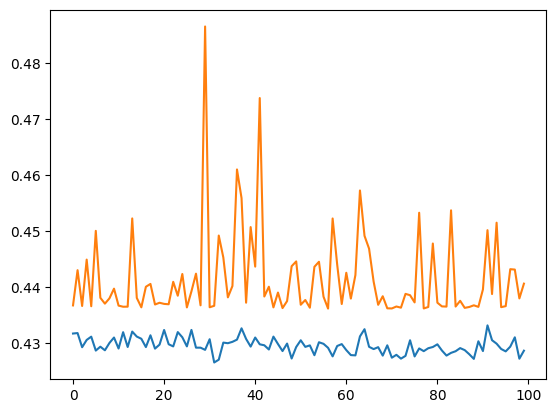

In [168]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

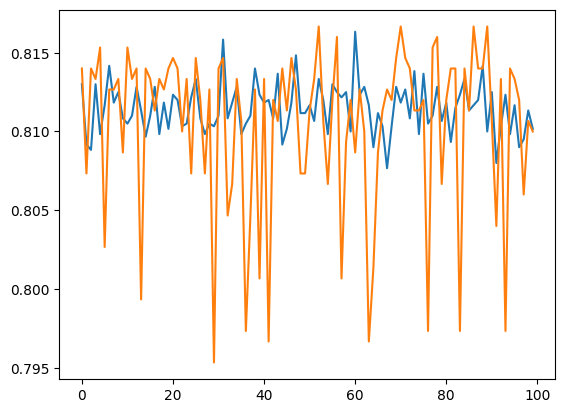

In [167]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [166]:
history.history

{'accuracy': [0.8130000233650208,
  0.809166669845581,
  0.8088333606719971,
  0.8130000233650208,
  0.8098333477973938,
  0.8116666674613953,
  0.8141666650772095,
  0.8118333220481873,
  0.8125,
  0.8108333349227905,
  0.8105000257492065,
  0.8109999895095825,
  0.812833309173584,
  0.8113333582878113,
  0.8096666932106018,
  0.8109999895095825,
  0.812833309173584,
  0.8098333477973938,
  0.8118333220481873,
  0.8101666569709778,
  0.812333345413208,
  0.8119999766349792,
  0.8103333115577698,
  0.8105000257492065,
  0.812166690826416,
  0.8133333325386047,
  0.8108333349227905,
  0.8098333477973938,
  0.8105000257492065,
  0.8103333115577698,
  0.8109999895095825,
  0.815833330154419,
  0.8108333349227905,
  0.8118333220481873,
  0.812833309173584,
  0.8098333477973938,
  0.8105000257492065,
  0.8109999895095825,
  0.8140000104904175,
  0.812333345413208,
  0.8118333220481873,
  0.8119999766349792,
  0.8108333349227905,
  0.8136666417121887,
  0.809166669845581,
  0.810166656970977